  ## Modelo de predição Score de crédito


In [ ]:
import pandas as pd 
import numpy as np
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("dados_usados/lending_club_loan_two.csv")

In [ ]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [ ]:
df.tail()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
396025,10000.0,60 months,10.99,217.38,B,B4,licensed bankere,2 years,RENT,40000.0,...,6.0,0.0,1990.0,34.3,23.0,w,INDIVIDUAL,0.0,0.0,"12951 Williams Crossing\r\nJohnnyville, DC 30723"
396026,21000.0,36 months,12.29,700.42,C,C1,Agent,5 years,MORTGAGE,110000.0,...,6.0,0.0,43263.0,95.7,8.0,f,INDIVIDUAL,1.0,0.0,"0114 Fowler Field Suite 028\r\nRachelborough, ..."
396027,5000.0,36 months,9.99,161.32,B,B1,City Carrier,10+ years,RENT,56500.0,...,15.0,0.0,32704.0,66.9,23.0,f,INDIVIDUAL,0.0,0.0,"953 Matthew Points Suite 414\r\nReedfort, NY 7..."
396028,21000.0,60 months,15.31,503.02,C,C2,"Gracon Services, Inc",10+ years,MORTGAGE,64000.0,...,9.0,0.0,15704.0,53.8,20.0,f,INDIVIDUAL,5.0,0.0,"7843 Blake Freeway Apt. 229\r\nNew Michael, FL..."
396029,2000.0,36 months,13.61,67.98,C,C2,Internal Revenue Service,10+ years,RENT,42996.0,...,3.0,0.0,4292.0,91.3,19.0,f,INDIVIDUAL,NaN,0.0,"787 Michelle Causeway\r\nBriannaton, AR 48052"


In [ ]:
colunas_traducao = {
    "loan_amnt": "valor_do_emprestimo",
    "term": "prazo_do_emprestimo",
    "int_rate": "taxa_de_juros",
    "installment": "valor_da_parcela",
    "grade": "classificacao_de_risco",
    "sub_grade": "sub_classificacao_de_risco",
    "emp_title": "cargo_profissao",
    "emp_length": "tempo_de_emprego",
    "home_ownership": "tipo_de_moradia",
    "annual_inc": "renda_anual",
    "verification_status": "status_de_verificacao_da_renda",
    "issue_d": "data_de_emissao_do_emprestimo",
    "loan_status": "status_do_emprestimo",
    "purpose": "finalidade_do_emprestimo",
    "title": "titulo_descricao_do_emprestimo",
    "dti": "relacao_divida_renda",
    "earliest_cr_line": "primeira_linha_de_credito",
    "open_acc": "contas_de_credito_abertas",
    "pub_rec": "registros_publicos_negativos",
    "revol_bal": "saldo_de_credito_rotativo",
    "revol_util": "utilizacao_do_credito_rotativo",
    "total_acc": "total_de_contas_de_credito",
    "initial_list_status": "status_inicial_de_listagem",
    "application_type": "tipo_de_aplicacao",
    "mort_acc": "contas_de_hipoteca",
    "pub_rec_bankruptcies": "registros_de_falencia",
    "address": "endereco"
}

In [ ]:
df = df.rename(columns = colunas_traducao)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   valor_do_emprestimo             396030 non-null  float64
 1   prazo_do_emprestimo             396030 non-null  object 
 2   taxa_de_juros                   396030 non-null  float64
 3   valor_da_parcela                396030 non-null  float64
 4   classificacao_de_risco          396030 non-null  object 
 5   sub_classificacao_de_risco      396030 non-null  object 
 6   cargo_profissao                 373103 non-null  object 
 7   tempo_de_emprego                377729 non-null  object 
 8   tipo_de_moradia                 396030 non-null  object 
 9   renda_anual                     396030 non-null  float64
 10  status_de_verificacao_da_renda  396030 non-null  object 
 11  data_de_emissao_do_emprestimo   396030 non-null  object 
 12  status_do_empres

In [ ]:
df.isnull().sum()

valor_do_emprestimo                   0
prazo_do_emprestimo                   0
taxa_de_juros                         0
valor_da_parcela                      0
classificacao_de_risco                0
sub_classificacao_de_risco            0
cargo_profissao                   22927
tempo_de_emprego                  18301
tipo_de_moradia                       0
renda_anual                           0
status_de_verificacao_da_renda        0
data_de_emissao_do_emprestimo         0
status_do_emprestimo                  0
finalidade_do_emprestimo              0
titulo_descricao_do_emprestimo     1756
relacao_divida_renda                  0
primeira_linha_de_credito             0
contas_de_credito_abertas             0
registros_publicos_negativos          0
saldo_de_credito_rotativo             0
utilizacao_do_credito_rotativo      276
total_de_contas_de_credito            0
status_inicial_de_listagem            0
tipo_de_aplicacao                     0
contas_de_hipoteca                37795


In [ ]:
df["contas_de_hipoteca"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 396030 entries, 0 to 396029
Series name: contas_de_hipoteca
Non-Null Count   Dtype  
--------------   -----  
358235 non-null  float64
dtypes: float64(1)
memory usage: 3.0 MB


In [ ]:
df["registros_de_falencia"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 396030 entries, 0 to 396029
Series name: registros_de_falencia
Non-Null Count   Dtype  
--------------   -----  
395495 non-null  float64
dtypes: float64(1)
memory usage: 3.0 MB


In [ ]:
df["utilizacao_do_credito_rotativo"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 396030 entries, 0 to 396029
Series name: utilizacao_do_credito_rotativo
Non-Null Count   Dtype  
--------------   -----  
395754 non-null  float64
dtypes: float64(1)
memory usage: 3.0 MB


In [ ]:
df["utilizacao_do_credito_rotativo"] = df["utilizacao_do_credito_rotativo"].fillna(df["utilizacao_do_credito_rotativo"].median())
df["contas_de_hipoteca"] = df["contas_de_hipoteca"].fillna(df["contas_de_hipoteca"].median())
df["registros_de_falencia"] = df["registros_de_falencia"].fillna(df["registros_de_falencia"].median())

In [ ]:
df.isna().sum()

valor_do_emprestimo                   0
prazo_do_emprestimo                   0
taxa_de_juros                         0
valor_da_parcela                      0
classificacao_de_risco                0
sub_classificacao_de_risco            0
cargo_profissao                   22927
tempo_de_emprego                  18301
tipo_de_moradia                       0
renda_anual                           0
status_de_verificacao_da_renda        0
data_de_emissao_do_emprestimo         0
status_do_emprestimo                  0
finalidade_do_emprestimo              0
titulo_descricao_do_emprestimo     1756
relacao_divida_renda                  0
primeira_linha_de_credito             0
contas_de_credito_abertas             0
registros_publicos_negativos          0
saldo_de_credito_rotativo             0
utilizacao_do_credito_rotativo        0
total_de_contas_de_credito            0
status_inicial_de_listagem            0
tipo_de_aplicacao                     0
contas_de_hipoteca                    0


In [ ]:
df["tempo_de_emprego"].value_counts()

tempo_de_emprego
10+ years    126041
2 years       35827
< 1 year      31725
3 years       31665
5 years       26495
1 year        25882
4 years       23952
6 years       20841
7 years       20819
8 years       19168
9 years       15314
Name: count, dtype: int64

In [ ]:
tempo_emprego = {
"10+ years" : 10,
"2 years" : 2,
"< 1 year" : 0,
"3 years" : 3,
"5 years" : 5,
"1 year" : 1, 
"4 years" : 4, 
"6 years" : 6,
"7 years" : 7 , 
"8 years" : 8,
"9 years" : 9
}

In [ ]:
df["tempo_de_emprego"] = df["tempo_de_emprego"].map(tempo_emprego)

In [ ]:
df["tempo_de_emprego"].value_counts()

tempo_de_emprego
10.0    126041
2.0      35827
0.0      31725
3.0      31665
5.0      26495
1.0      25882
4.0      23952
6.0      20841
7.0      20819
8.0      19168
9.0      15314
Name: count, dtype: int64

In [ ]:
df["tempo_de_emprego"] = df["tempo_de_emprego"].replace(np.nan, df["tempo_de_emprego"].median())

In [ ]:
df["tempo_de_emprego"].sample(20)

203072     7.0
275685     2.0
53795     10.0
289547     0.0
145535     5.0
12516      1.0
207642    10.0
325725     8.0
374861     9.0
206556    10.0
285012    10.0
283264     2.0
374261     4.0
56643      0.0
284480     6.0
153728     7.0
130136     5.0
179516     7.0
89667     10.0
21978     10.0
Name: tempo_de_emprego, dtype: float64

In [ ]:
df = df.drop(["titulo_descricao_do_emprestimo", "cargo_profissao", "status_inicial_de_listagem", "status_de_verificacao_da_renda"], axis=1)

In [ ]:
df = df.drop(["classificacao_de_risco", "sub_classificacao_de_risco"], axis=1)

In [ ]:
df.isnull().sum()

valor_do_emprestimo               0
prazo_do_emprestimo               0
taxa_de_juros                     0
valor_da_parcela                  0
tempo_de_emprego                  0
tipo_de_moradia                   0
renda_anual                       0
data_de_emissao_do_emprestimo     0
status_do_emprestimo              0
finalidade_do_emprestimo          0
relacao_divida_renda              0
primeira_linha_de_credito         0
contas_de_credito_abertas         0
registros_publicos_negativos      0
saldo_de_credito_rotativo         0
utilizacao_do_credito_rotativo    0
total_de_contas_de_credito        0
tipo_de_aplicacao                 0
contas_de_hipoteca                0
registros_de_falencia             0
endereco                          0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   valor_do_emprestimo             396030 non-null  float64
 1   prazo_do_emprestimo             396030 non-null  object 
 2   taxa_de_juros                   396030 non-null  float64
 3   valor_da_parcela                396030 non-null  float64
 4   tempo_de_emprego                396030 non-null  float64
 5   tipo_de_moradia                 396030 non-null  object 
 6   renda_anual                     396030 non-null  float64
 7   data_de_emissao_do_emprestimo   396030 non-null  object 
 8   status_do_emprestimo            396030 non-null  object 
 9   finalidade_do_emprestimo        396030 non-null  object 
 10  relacao_divida_renda            396030 non-null  float64
 11  primeira_linha_de_credito       396030 non-null  object 
 12  contas_de_credit

In [ ]:
colunas_numericas = []
colunas_texto = []
for i in df.columns.tolist():
  if df[i].dtype == "int64" or df[i].dtype == "float64":
     colunas_numericas.append(i)
  else:
     colunas_texto.append(i)

In [ ]:
colunas_numericas

['valor_do_emprestimo',
 'taxa_de_juros',
 'valor_da_parcela',
 'tempo_de_emprego',
 'renda_anual',
 'relacao_divida_renda',
 'contas_de_credito_abertas',
 'registros_publicos_negativos',
 'saldo_de_credito_rotativo',
 'utilizacao_do_credito_rotativo',
 'total_de_contas_de_credito',
 'contas_de_hipoteca',
 'registros_de_falencia']

In [ ]:
colunas_texto

['prazo_do_emprestimo',
 'tipo_de_moradia',
 'data_de_emissao_do_emprestimo',
 'status_do_emprestimo',
 'finalidade_do_emprestimo',
 'primeira_linha_de_credito',
 'tipo_de_aplicacao',
 'endereco']

In [ ]:
colunas_codificadas = {}

for i in df.columns:
    if df[i].dtype == "object":
     codificador = LabelEncoder()
     df[i] = codificador.fit_transform(df[i])
     colunas_codificadas[i] = codificador

In [ ]:
colunas_codificadas

{'prazo_do_emprestimo': LabelEncoder(),
 'tipo_de_moradia': LabelEncoder(),
 'data_de_emissao_do_emprestimo': LabelEncoder(),
 'status_do_emprestimo': LabelEncoder(),
 'finalidade_do_emprestimo': LabelEncoder(),
 'primeira_linha_de_credito': LabelEncoder(),
 'tipo_de_aplicacao': LabelEncoder(),
 'endereco': LabelEncoder()}

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   valor_do_emprestimo             396030 non-null  float64
 1   prazo_do_emprestimo             396030 non-null  int64  
 2   taxa_de_juros                   396030 non-null  float64
 3   valor_da_parcela                396030 non-null  float64
 4   tempo_de_emprego                396030 non-null  float64
 5   tipo_de_moradia                 396030 non-null  int64  
 6   renda_anual                     396030 non-null  float64
 7   data_de_emissao_do_emprestimo   396030 non-null  int64  
 8   status_do_emprestimo            396030 non-null  int64  
 9   finalidade_do_emprestimo        396030 non-null  int64  
 10  relacao_divida_renda            396030 non-null  float64
 11  primeira_linha_de_credito       396030 non-null  int64  
 12  contas_de_credit

In [ ]:
#df.to_csv("dados_para_modelo", sep=",", encoding="utf-8", index=False)

<bound method Figure.show of <Figure size 1200x800 with 2 Axes>>

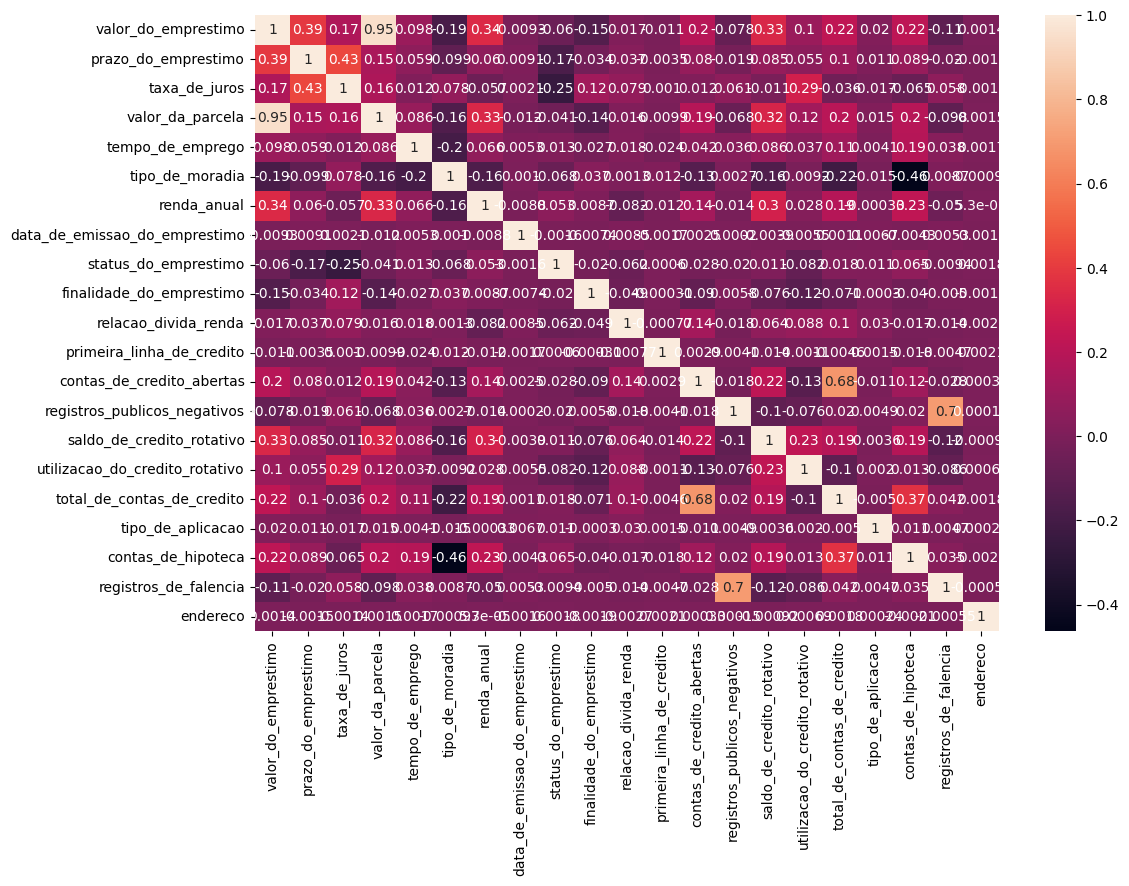

In [ ]:
corr = df.corr()

grafico_calor = plt.figure(figsize=(12, 8))

sns.heatmap(corr, annot=True)

grafico_calor.show